### Daten Weg-Zeit-Diagramme

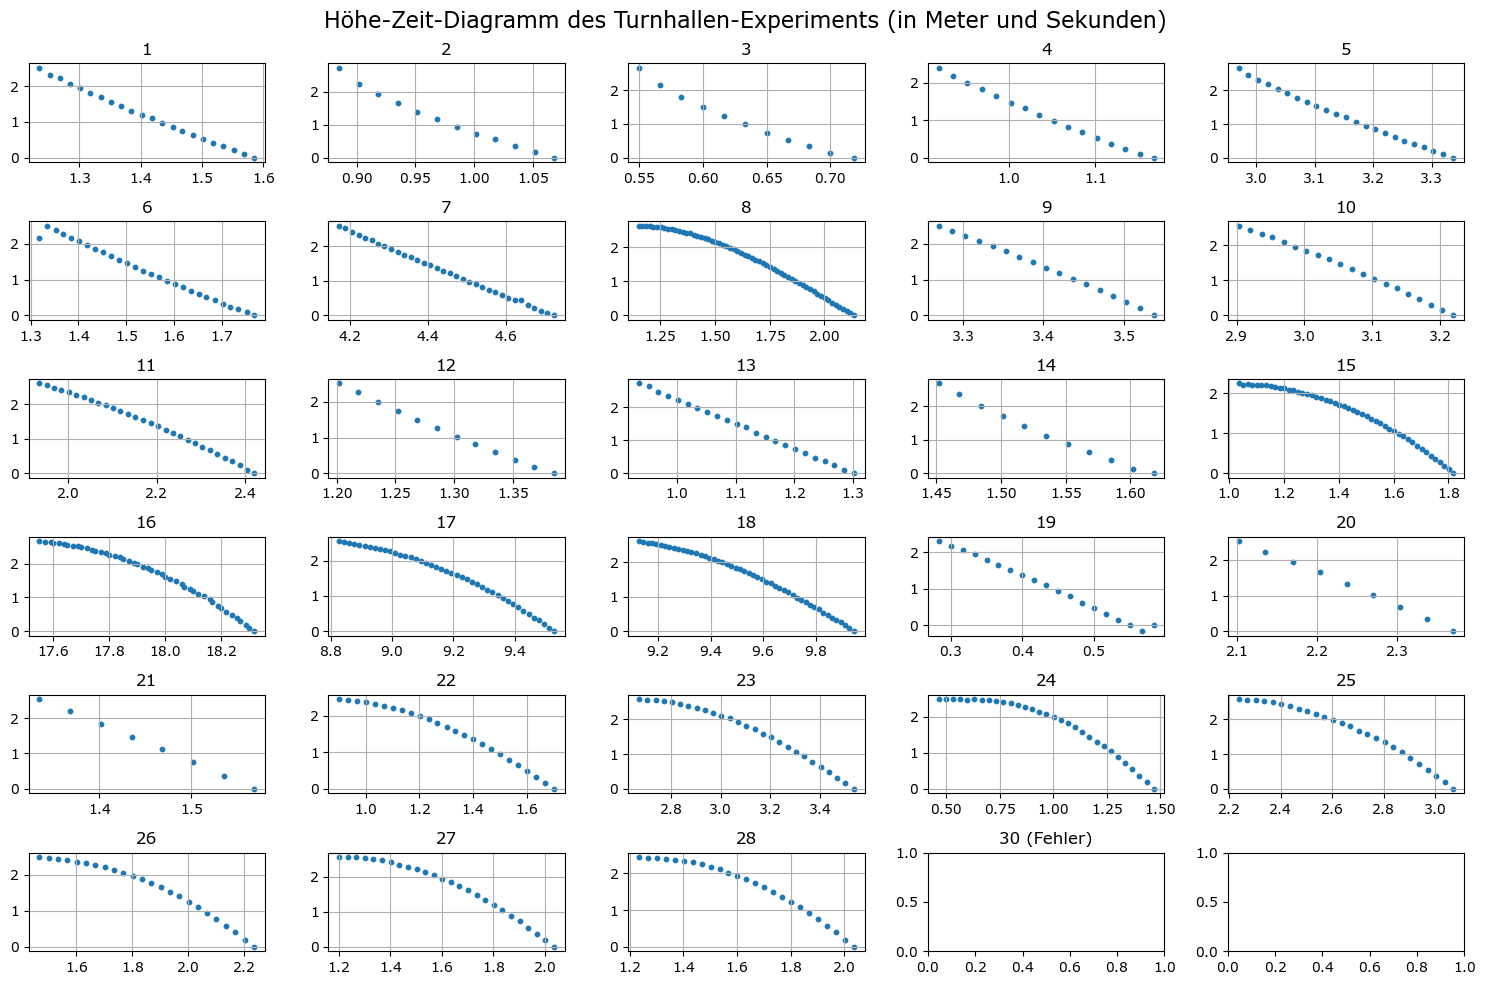

In [1]:
import csv
import matplotlib.pyplot as plt
import math
import numpy as np

n = 28  
cols = 5
rows = math.ceil(n / cols)
g = 9.81
frames = 60 
beschleunigung_pro_frame = g/frames

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for idx, i in enumerate(range(2, 31)):
    file_path = f"DGL_Aufnahme_{i}.csv"
    x, y = [], []
    
    

    try:
        with open(file_path, newline='', encoding='utf-8') as csvfile:
            reader = csv.reader(csvfile)
            next(reader)

            for row in reader:
                x.append(float(row[0]))
                y.append(float(row[2]))

            letzter_wert = y[-1]
            y = [(wert - letzter_wert) for wert in y]
            y = [wert /630*2.5 for wert in y]
        axes[idx].scatter(x, y, s=10)
        axes[idx].set_title(f"{i-1}")
        axes[idx].grid()
    
    except:
        axes[idx].set_title(f"{i} (Fehler)")
x = []
fig.suptitle("Höhe-Zeit-Diagramm des Turnhallen-Experiments (in Meter und Sekunden)", fontsize=16)
plt.tight_layout()
plt.show()


### Höhe-Zeit-Diagramme mit Diagramm ohne LW


In [ ]:
import csv
import matplotlib.pyplot as plt
import math
import numpy as np

file_path_num = int(input("Welche Aufnahme? (0-30): "))
file_path = f"DGL_{file_path_num}.csv"

weight = float(input("Das Gewicht des Objektes in Gramm: "))
sf = float(input("Wie gross ist die Stirnfläche des Objektes in m2: "))

g = 9.81
frames = int(input("Mit vielen Frames pro Sekunde wurde das Video aufgenommen?: "))
beschleunigung_pro_frame = g/frames


x = []
y = []
with open(file_path, newline='', encoding='utf-8') as csvfile:
            reader = csv.reader(csvfile)
            next(reader)

            for row in reader:
                x.append(float(row[0]))
                y.append(float(row[2]))



y2 = [1000- 0.5 * beschleunigung_pro_frame*s * (s/frames)**2 /630*2.5 for s in range(len(y))] #600/3.5 pixel/meter
x2 = np.arange(0,len(y))/frames

plt.figure()
plt.scatter(x, y)
plt.title("Graph 1")

plt.figure()
plt.scatter(x2, y2)
plt.title("Graph 2")

plt.show()

### Geschwindigkeit-Zeit Diagramm

In [20]:
import csv
import matplotlib.pyplot as plt
import math
import numpy as np

file_path_num = int(input("Welche Aufnahme? (0-30): "))
file_path = f"DGL_Aufnahme_{file_path_num}.csv"

frames = int(input("Wie viele frames?: "))

g = 9.81
beschleunigung_pro_frame = g/frames

x = []
y = []
with open(file_path, newline='', encoding='utf-8') as csvfile:
            reader = csv.reader(csvfile)
            next(reader)

            for row in reader:
                x.append(float(row[0]))
                y.append(float(row[2]))

y2 = [1000- 0.5 * beschleunigung_pro_frame*s * (s/frames)**2 /630*2.5 for s in range(len(y))] #630/2.5 pixel/meter oder /955* 3.40 -> für zweites Experiment
x2 = np.arange(0,len(y))/frames

y_g = []
x_g = np.arange(len(y)-1)
print(x)
for i in range(len(x)-1):
    y_g.append((y[i]-y[i+1])/frames)

print(y_g)
print(x_g)
plt.figure()
plt.scatter(x_g, y_g)
plt.title(f"Graph {file_path_num}")

Welche Aufnahme? (0-30):  30
Wie viele frames?:  30


FileNotFoundError: [Errno 2] No such file or directory: 'DGL_Aufnahme_30.csv'

### Ableitungen aller Punkte

Wie viele Frames pro Sekunde?:  30


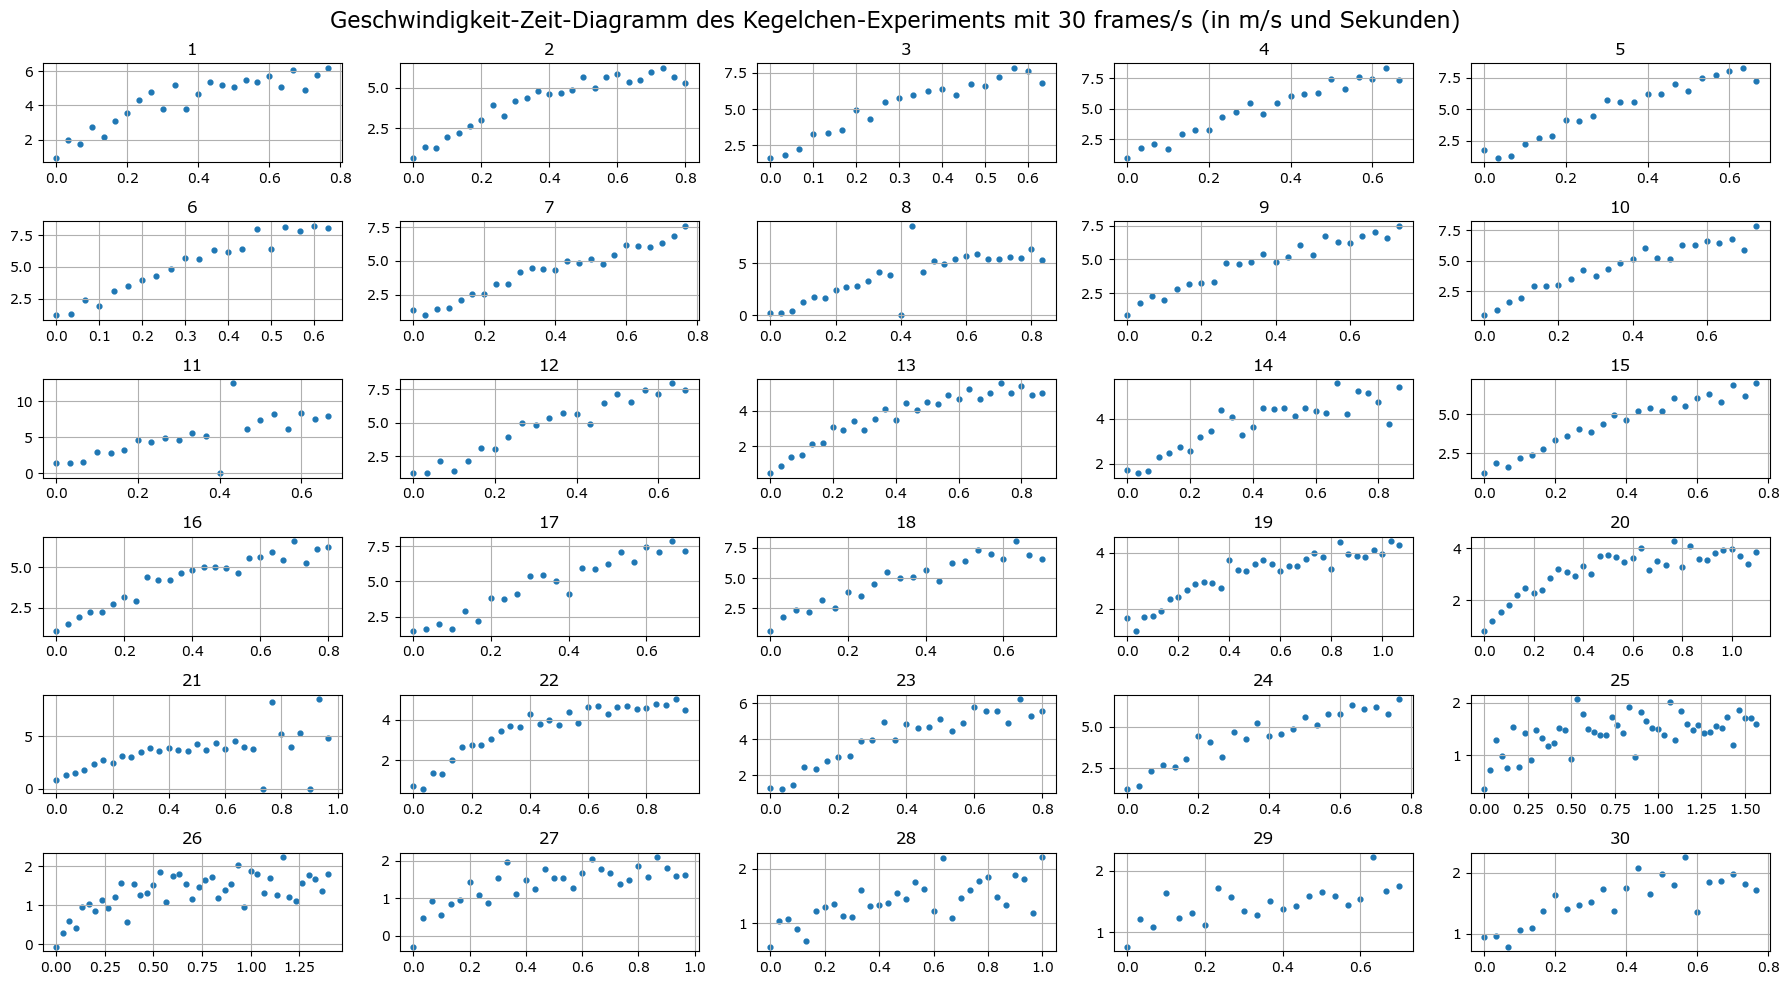

In [14]:
import csv
import matplotlib.pyplot as plt
import math
import os

frames = int(input("Wie viele Frames pro Sekunde?: "))

start = 2
ende = 31   # 1 - 21 sind mit 60 frames / s 21-28 sind mit 30 frames/s
u = 0

anzahl = ende - start + 1
cols = 5
rows = math.ceil(anzahl / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = axes.flatten()

for idx, i in enumerate(range(start, ende + 1)):
    if i >= 19:
        i += 1
        u = 1
    file_path = f"DGL_{i}.csv"

    if not os.path.exists(file_path):
        axes[idx].set_visible(False)
        continue

    x = []
    y = []
    with open(file_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)

        for row in reader:
            x.append(float(row[0]))
            y.append(float(row[2]))

        letzter_wert = y[-1]
        y = [(wert - letzter_wert) /630*2.5 for wert in y]

    y_g = []
    x_g = []

    for j in range(len(y) - 1):
        y_g.append((y[j] - y[j + 1]) *frames)# in m/s
        x_g.append(j/frames)

    axes[idx].scatter(x_g, y_g, s=12)
    axes[idx].set_title(f"{i-1-u}")
    axes[idx].grid(True)


for k in range(idx + 1, len(axes)):
    axes[k].set_visible(False)

fig.suptitle("Geschwindigkeit-Zeit-Diagramm des Kegelchen-Experiments mit 30 frames/s (in m/s und Sekunden)", fontsize=16)
plt.tight_layout()
plt.show()

### 2te Ableitung - Beschleunigungsdiagramm

Wie viele Frames pro Sekunde?:  60


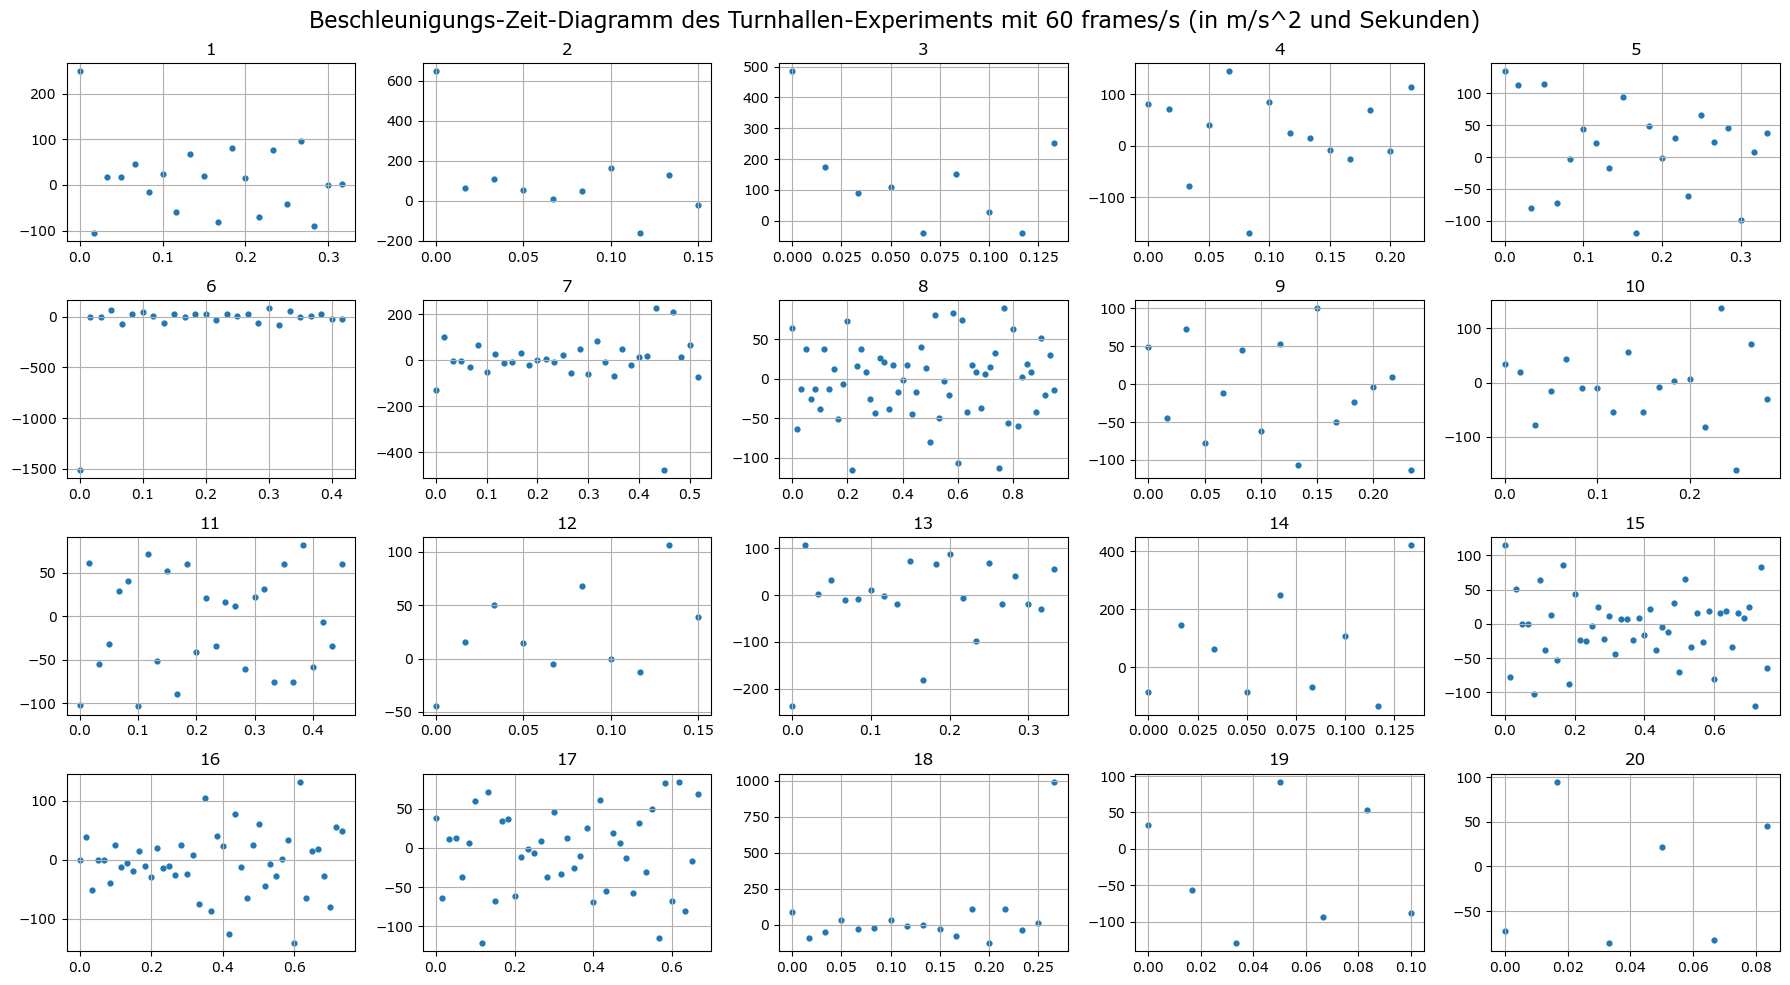

In [5]:
import csv
import matplotlib.pyplot as plt
import math
import os

frames = int(input("Wie viele Frames pro Sekunde?: "))

start = 2
ende = 21
u = 0
anzahl = ende - start + 1
cols = 5
rows = math.ceil(anzahl / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = axes.flatten()

for idx, i in enumerate(range(start, ende + 1)):
    if i >= 19:
        i += 1
        u = 1
    file_path = f"DGL_Aufnahme_{i}.csv"

    if not os.path.exists(file_path):
        axes[idx].set_visible(False)
        continue

    x = []
    y = []

    with open(file_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)

        for row in reader:
            x.append(float(row[0]))
            y.append(float(row[2]))

    y_g = []
    x_g = []

    for j in range(len(y) - 1):
        y_g.append((y[j] - y[j + 1]) * frames/955*3.4 )
        x_g.append(x[j])


    
    y_a = []
    x_a = []

    for h in range(len(y_g) - 1):
        y_a.append((y_g[h] - y_g[h + 1]) *frames)
        x_a.append(h/frames)

    axes[idx].scatter(x_a, y_a, s=12)
    axes[idx].set_title(f"{i-u-1}")
    axes[idx].grid(True)


for k in range(idx + 1, len(axes)):
    axes[k].set_visible(False)


fig.suptitle("Beschleunigungs-Zeit-Diagramm des Turnhallen-Experiments mit 60 frames/s (in m/s^2 und Sekunden)", fontsize=16)
plt.tight_layout()
plt.show()

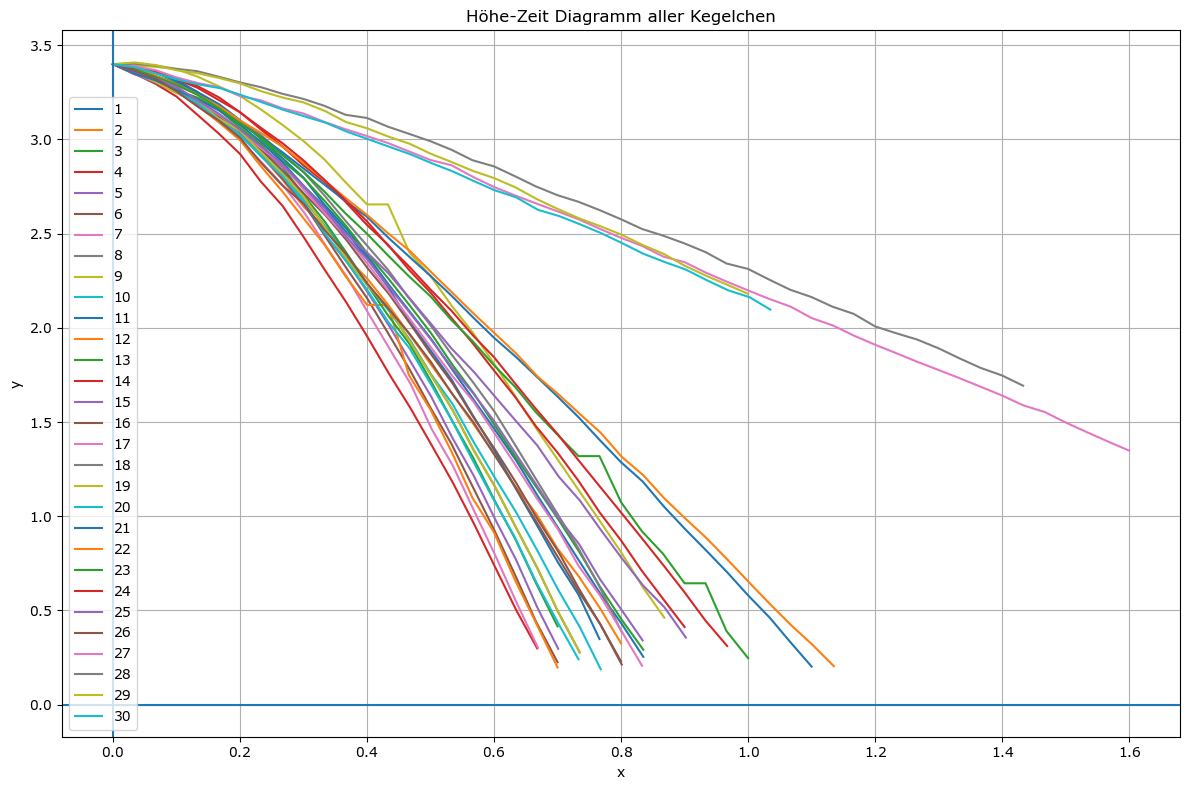

In [70]:
import csv
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(1, 31):
    file_path = f"DGL_{i}.csv"
    x, y = [], []

    try:
        with open(file_path, newline='', encoding='utf-8') as csvfile:
            reader = csv.reader(csvfile)
            next(reader)

            for row in reader:
                x.append(float(row[0]))
                y.append(float(row[2]))

        if len(x) > 0:
            x0 = x[0]
            y0 = y[0]

            x_shifted = [xi - x0 for xi in x]
            y_shifted = [yi - y0 for yi in y]
            y_shifted = [wert   /955*3.4 + 3.4 for wert in y_shifted]

            plt.plot(x_shifted, y_shifted, label=f"{i}")

    except:
        print(f"Fehler bei Datei {file_path}")

plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Höhe-Zeit Diagramm aller Kegelchen")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Was ist der Cw-Wert?:  0.4
Was ist der Druck?:  1.15
Was ist die Masse des Objektes?:  0.4


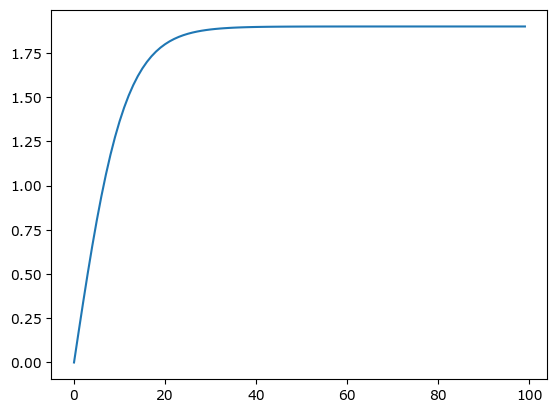

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

cw = float(input("Was ist der Cw-Wert?: "))
g = 9.81
p = float(input("Was ist der Druck?: "))
m = float(input("Was ist die Masse des Objektes?: "))

time = np.arange(0,100)
v = []
for t in range(len(time)):
    velocity = np.tanh((0.1*t*g*cw*p)/2*m)* math.sqrt((2*m*g)*cw*p)
    v.append(velocity)

plt.plot(time,v)
plt.show()

### Annäherung DGL an Datenpunkte

Wie viele Frames pro Sekunde?:  30


Das Koordinatensystem 2 hat Strinfläche 0.008 und Gewicht 0.02
Das Koordinatensystem 3 hat Strinfläche 0.008 und Gewicht 0.02
Das Koordinatensystem 4 hat Strinfläche 0.004 und Gewicht 0.02
Das Koordinatensystem 5 hat Strinfläche 0.004 und Gewicht 0.02
Das Koordinatensystem 6 hat Strinfläche 0.002 und Gewicht 0.02
Das Koordinatensystem 7 hat Strinfläche 0.002 und Gewicht 0.02
Das Koordinatensystem 8 hat Strinfläche 0.008 und Gewicht 0.015
Das Koordinatensystem 9 hat Strinfläche 0.008 und Gewicht 0.015
Das Koordinatensystem 10 hat Strinfläche 0.004 und Gewicht 0.015
Das Koordinatensystem 11 hat Strinfläche 0.004 und Gewicht 0.015
Das Koordinatensystem 12 hat Strinfläche 0.002 und Gewicht 0.015
Das Koordinatensystem 13 hat Strinfläche 0.002 und Gewicht 0.015
Das Koordinatensystem 14 hat Strinfläche 0.008 und Gewicht 0.01
Das Koordinatensystem 15 hat Strinfläche 0.008 und Gewicht 0.01
Das Koordinatensystem 16 hat Strinfläche 0.004 und Gewicht 0.01
Das Koordinatensystem 17 hat Strinfläche 0

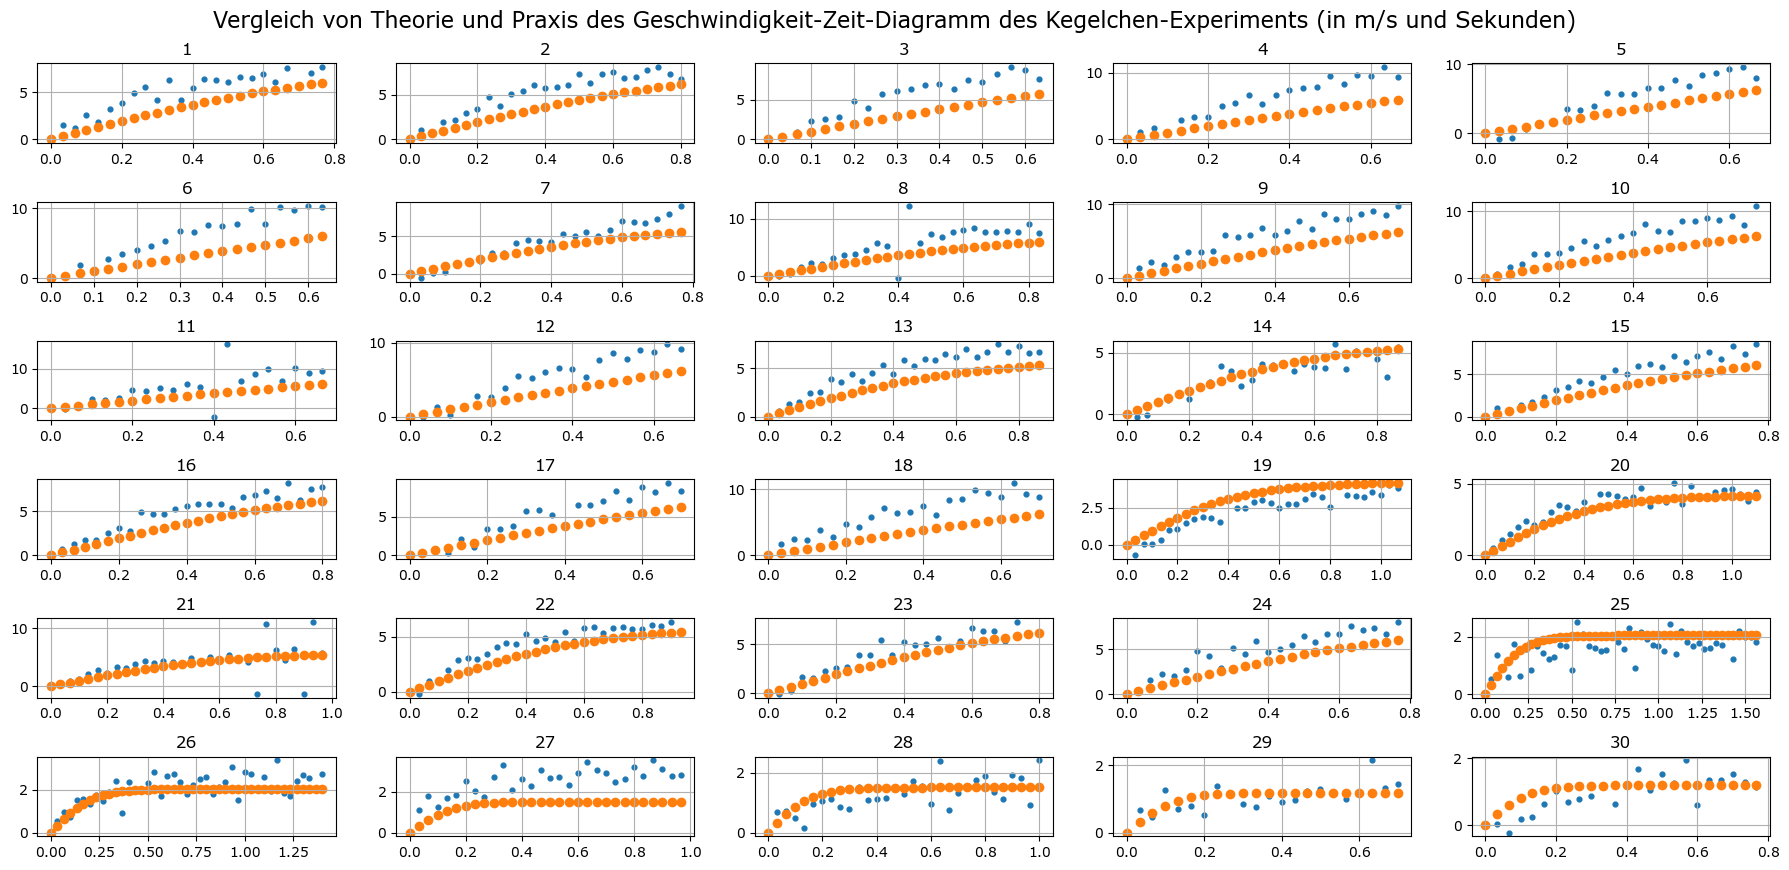

In [20]:
import csv
import matplotlib.pyplot as plt
import math
import os
import numpy as np

frames = int(input("Wie viele Frames pro Sekunde?: "))

start = 2
ende = 32  

g = 9.81
cw = 0.6 # geschätzter Wert ChatGPT bei Kegelchen
u = 0

C = 1

gewichte = [20/1000, 15/1000, 10/1000, 5/1000, 0.1/1000]




stirnflaeche_rot = 80 / 10000      # cm^2 -> m^2
stirnflaeche_orange = 40 / 10000
stirnflaeche_gelb = 20 / 10000
stirnflächen = [stirnflaeche_rot,stirnflaeche_orange,stirnflaeche_gelb]

anzahl = ende - start + 1
cols = 5
rows = math.ceil(anzahl / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = axes.flatten()

for idx, i in enumerate(range(start, ende + 1)):
    if i >= 19:
        i += 1
        u = 1
    file_path = f"DGL_{i}.csv"
    if i >= 19:
        i -= 1
    if not os.path.exists(file_path):
        axes[idx].set_visible(False)
        continue

    x = []
    y = []

    with open(file_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)

        for row in reader:
            x.append(float(row[0]))
            y.append(float(row[2]))

        letzter_wert = y[-1]
        y = [(wert - letzter_wert) / 600 * 3.5 for wert in y]


    
    y_g = []
    x_g = []
    u = i-start
    g_id = int(u/6)
    if g_id > 4:
        g_id = 4

    A_i = u%6
    A_i = int(A_i/2)
    A = stirnflächen[A_i]
    p = 1.15
    m = gewichte[g_id]
    if i == 26 or i ==27:
        m = 1.17/1000

    if i == 28 or i ==29:
        m = 0.64/1000

    if i == 28 or i ==29:
        m = 0.32/1000

    print(f"Das Koordinatensystem {i} hat Strinfläche {A} und Gewicht {m}")


    for j in range(len(y) - 1):
        y_g.append((y[j] - y[j + 1]) *frames)# in m/s
        x_g.append(j/frames)
    
    y_g = [val - y_g[0] for val in y_g]

    time = len(x_g)
    v = []
    for t in range(time):
        #velocity = np.tanh((1/frames*t*g*cw*A*p)/(2*m))* math.sqrt((2*m*g)/(cw*p*A))
        #velocity = math.sqrt((2*m*g)/(cw*p*A)) * np.tanh(t/frames * math.sqrt((g*cw*p*A)/(2*m)))
        k = cw*p*A/(2*m)
        velocity = math.sqrt(g/k)* (C*np.e**(2*t/frames*math.sqrt(g*k))-1)/(C*np.e**(2*t/frames*math.sqrt(g*k))+1)
        v.append(velocity)

    axes[idx].scatter(x_g, y_g, s=12)
    axes[idx].scatter(x_g,v)
    axes[idx].set_title(f"{i-1}")
    axes[idx].grid(True)


for k in range(idx + 1, len(axes)):
    axes[k].set_visible(False)
fig.suptitle("Vergleich von Theorie und Praxis des Geschwindigkeit-Zeit-Diagramm des Kegelchen-Experiments (in m/s und Sekunden)", fontsize=16)
plt.tight_layout()
plt.show()

Wie viele Frames pro Sekunde?:  30
Welche Datei (z. B. 1 für DGL_1.csv)?:  3


Datei 3 hat Stirnflaeche 0.004 m^2 und Gewicht 0.02 kg


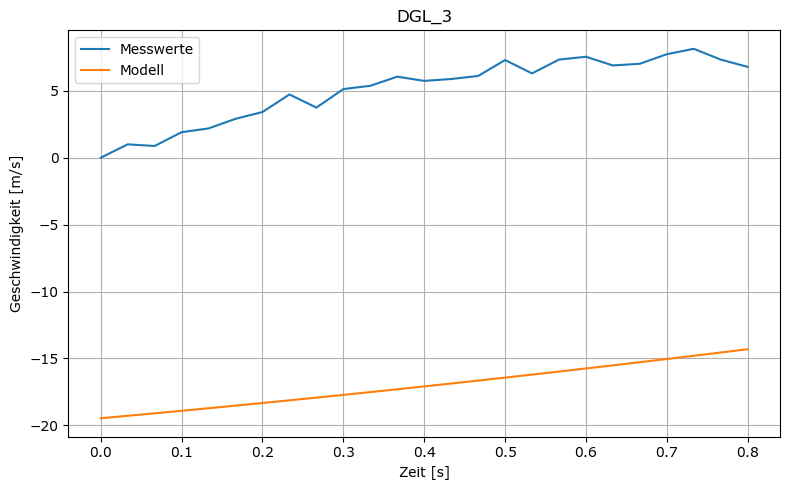

In [33]:
import csv
import matplotlib.pyplot as plt
import math
import os
import numpy as np

frames = int(input("Wie viele Frames pro Sekunde?: "))
datei_nummer = int(input("Welche Datei (z. B. 1 für DGL_1.csv)?: "))

g = 9.81
cw = 0.1
C = 0.2

gewichte = [20/1000, 15/1000, 10/1000, 5/1000, 0.1/1000]

stirnflaeche_rot = 80 / 10000
stirnflaeche_orange = 40 / 10000
stirnflaeche_gelb = 20 / 10000
stirnflaechen = [stirnflaeche_rot, stirnflaeche_orange, stirnflaeche_gelb]

file_path = f"DGL_{datei_nummer}.csv"

if not os.path.exists(file_path):
    print(f"Datei {file_path} nicht gefunden.")
    exit()

x = []
y = []

with open(file_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)

    for row in reader:
        x.append(float(row[0]))
        y.append(float(row[2]))

letzter_wert = y[-1]
y = [(wert - letzter_wert) / 600 * 3.5 for wert in y]

y_g = []
x_g = []

u = datei_nummer - 1
g_id = int(u / 6)
if g_id > 4:
    g_id = 4

A_i = datei_nummer % 6
A_i = int(A_i / 2)
A = stirnflaechen[A_i]

p = 1.15
m = gewichte[g_id]

print(f"Datei {datei_nummer} hat Stirnflaeche {A} m^2 und Gewicht {m} kg")

for j in range(len(y) - 1):
    y_g.append((y[j] - y[j + 1]) * frames)
    x_g.append(j / frames)

y_g = [val - y_g[0] for val in y_g]

time = len(x_g)
v = []

k = cw * p * A / (2 * m)

for t in range(time):
    velocity = math.sqrt(g / k) * (
        (C * np.e**(2 * t / frames * math.sqrt(g * k)) - 1) /
        (C * np.e**(2 * t / frames * math.sqrt(g * k)) + 1)
    )
    v.append(velocity)

plt.figure(figsize=(8, 5))
plt.plot(x_g, y_g, label="Messwerte")
plt.plot(x_g, v, label="Modell")
plt.title(f"DGL_{datei_nummer}")
plt.xlabel("Zeit [s]")
plt.ylabel("Geschwindigkeit [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import csv
import matplotlib.pyplot as plt
import math
import os
import numpy as np

# -----------------------------
# Eingaben
# -----------------------------
#dateiname = input("Wie heisst die CSV-Datei? (z.B. DGL_2.csv): ")
#frames = int(input("Wie viele Frames pro Sekunde?: "))
#m = float(input("Masse in kg eingeben (z.B. 0.02): "))
#A = float(input("Stirnflaeche in m^2 eingeben (z.B. 0.008): "))
#cw = float(input("cw-Wert eingeben (z.B. 0.6): "))
#C = float(input("C-Wert eingeben (z.B. 1): "))
#p = float(input("Luftdichte in kg/m^3 eingeben (z.B. 1.15): "))

dateiname = "DGL_Aufnahme_3.csv"
frames = 60
m = 0.005
A = 0.00332
cw = 0.6
C = -1.5
p = 1.15

g = 9.81

# -----------------------------
# Datei prüfen
# -----------------------------
if not os.path.exists(dateiname):
    print(f"Datei '{dateiname}' wurde nicht gefunden.")
    exit()

# -----------------------------
# CSV laden
# -----------------------------
x = []
y = []

with open(dateiname, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # Überschrift überspringen

    for row in reader:
        x.append(float(row[0]))
        y.append(float(row[2]))

# -----------------------------
# y-Werte umrechnen
# -----------------------------
letzter_wert = y[-1]
y = [(wert - letzter_wert) / 600 * 3.5 for wert in y]

# -----------------------------
# Experimentelle Geschwindigkeit berechnen
# -----------------------------
y_g = []
x_g = []

for j in range(len(y) - 1):
    y_g.append((y[j] - y[j + 1]) * frames)   # m/s
    x_g.append(j / frames)

# Start bei 0 setzen
y_g = [val - y_g[0] for val in y_g]

# -----------------------------
# Theoretische Geschwindigkeit berechnen
# -----------------------------
v = []
k = cw * p * A / (2 * m)

for t in x_g:
    velocity = math.sqrt(g / k) * (
        (C * np.e**(2 * t * math.sqrt(g * k)) - 1) /
        (C * np.e**(2 * t * math.sqrt(g * k)) + 1)
    )
    v.append(velocity)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(x_g, y_g, s=20, label="Praxis")
plt.scatter(x_g, v, s=20, label="Theorie")

plt.title("Vergleich von Theorie und Praxis im Geschwindigkeit-Zeit-Diagramm")
plt.xlabel("Zeit in s")
plt.ylabel("Geschwindigkeit in m/s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

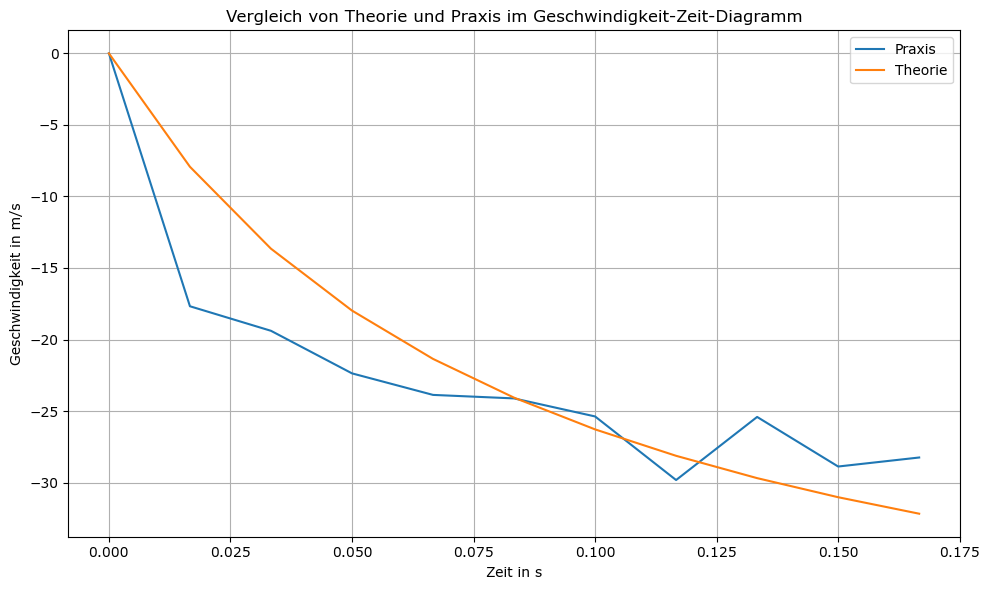

In [8]:
import csv
import matplotlib.pyplot as plt
import math
import os
import numpy as np

# -----------------------------
# Eingaben
# -----------------------------

#dateiname = input("Wie heisst die CSV-Datei? (z.B. DGL_2.csv): ")
#frames = int(input("Wie viele Frames pro Sekunde?: "))
#m = float(input("Masse in kg eingeben (z.B. 0.02): "))
#A = float(input("Stirnflaeche in m^2 eingeben (z.B. 0.008): "))
#cw = float(input("cw-Wert eingeben (z.B. 0.6): "))
#C = float(input("C-Wert eingeben (z.B. 1): "))
#p = float(input("Luftdichte in kg/m^3 eingeben (z.B. 1.15): "))

dateiname = "DGL_Aufnahme_3.csv"
frames = 60
m = 0.005
A = 0.00332
cw = 0.6
C = -1.3
p = 1.15

g = 9.81
g = 9.81

# -----------------------------
# Datei prüfen
# -----------------------------
if not os.path.exists(dateiname):
    print(f"Datei '{dateiname}' wurde nicht gefunden.")
    exit()

# -----------------------------
# CSV laden
# -----------------------------
x = []
y = []

with open(dateiname, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)

    for row in reader:
        x.append(float(row[0]))
        y.append(float(row[2]))

# -----------------------------
# y-Werte umrechnen
# -----------------------------
letzter_wert = y[-1]
y = [(wert - letzter_wert) / 600 * 3.5 for wert in y]

# -----------------------------
# Experimentelle Geschwindigkeit
# -----------------------------
y_g = []
x_g = []

for j in range(len(y) - 1):
    y_g.append((y[j] - y[j + 1]) * frames)
    x_g.append(j / frames)

# Praxis bei 0 starten lassen
y_g = [val - y_g[0] for val in y_g]

# -----------------------------
# Theoretische Geschwindigkeit
# -----------------------------
v = []
k = cw * p * A / (2 * m)

for t in x_g:
    velocity = math.sqrt(g / k) * (
        (C * np.e**(2 * t * math.sqrt(g * k)) - 1) /
        (C * np.e**(2 * t * math.sqrt(g * k)) + 1)
    )
    v.append(velocity)

# Theorie auch bei 0 starten lassen
v = [val - v[0] for val in v]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(x_g, y_g, label="Praxis")
plt.plot(x_g, v, label="Theorie")

plt.title("Vergleich von Theorie und Praxis im Geschwindigkeit-Zeit-Diagramm")
plt.xlabel("Zeit in s")
plt.ylabel("Geschwindigkeit in m/s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#dateiname = input("Wie heisst die CSV-Datei? (z.B. DGL_2.csv): ")
#frames = int(input("Wie viele Frames pro Sekunde?: "))
#m = float(input("Masse in kg eingeben (z.B. 0.02): "))
#A = float(input("Stirnflaeche in m^2 eingeben (z.B. 0.008): "))
#cw = float(input("cw-Wert eingeben (z.B. 0.6): "))
#C = float(input("C-Wert eingeben (z.B. 1): "))
#p = float(input("Luftdichte in kg/m^3 eingeben (z.B. 1.15): "))

dateiname = "DGL_Aufnahme_3.csv"
frames = 60
m = 0.005
A = 0.00332
cw = 0.6
C = -1.5
p = 1.15

g = 9.81

# Numerisches Lösungsverfahren

### v`= p0 * e ** (-h/hs) *k * v**2 + GM/(r-h)^2

Wie hoch ist die Temperatur in Grad?:  15
Wie lautet der Cw-Wert des Objektes?:  0.5
Wie gross ist die Stirnfläche in m^2?:  0.05
Wie schwer ist das Objekt in kg?:  0.05
Auf wie viel Metern höhe wird das Objekt geworfen?:  200000


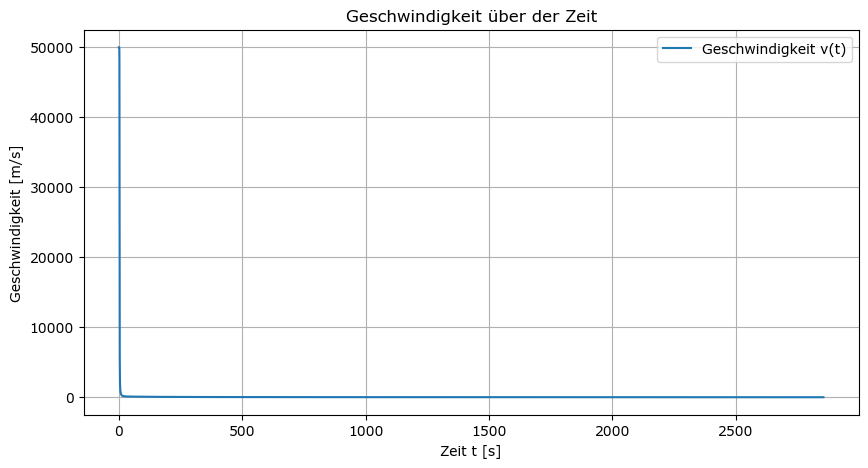

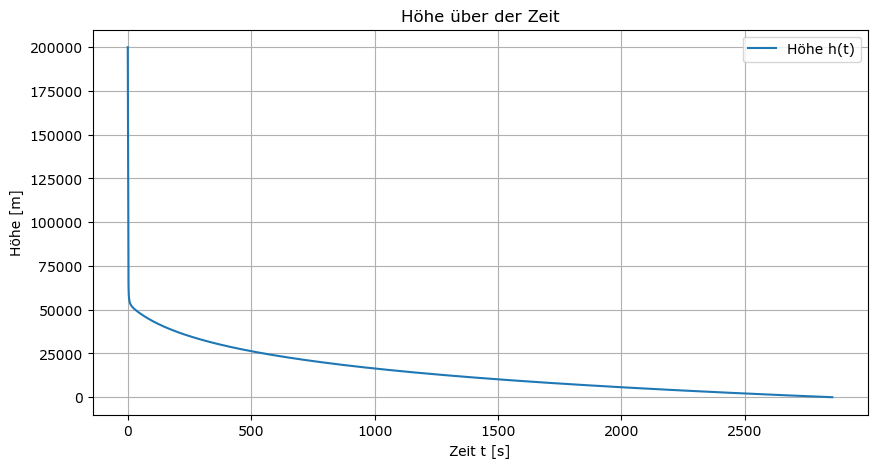

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

             
# https://de.wikipedia.org/wiki/Barometrische_Höhenformel


T = float(input("Wie hoch ist die Temperatur in Grad?: "))
T = T + 273.15 #-> in Kelvin
cw = float(input("Wie lautet der Cw-Wert des Objektes?: "))                
A = float(input("Wie gross ist die Stirnfläche in m^2?: "))         
m = float(input("Wie schwer ist das Objekt in kg?: "))         
hoehe = float(input("Auf wie viel Metern höhe wird das Objekt geworfen?: "))

k = (cw * A) / (2 * m)

G = 6.6743e-11      # Gravitationskonstante  
M_erde = 5.972e24    # Masse Erde
R_erde = 6.371e6      # Radius Erde
g = 9.81 
M_luft = 0.02897        # mol-Masse der Luft (kg / mol)
p0 = 1.225            # Luftdichte auf Meereshöhe (kg / m^3)
R = 8.314   #Gaskonstante

hs = (R * T) / (M_luft * g) # Formel aus Wikipedia -> sehen wir zur Vereinfachung a
hoehen = []
def euler(v0, t0,p0, f,hs, G, R_erde, k, M_erde, dt, n):
    v = v0
    t = t0
    h = hoehe
    results = [(t, v)]
    
    for i in range(n):
        v = v + dt * f(t, v, p0, hs, G,  R_erde, k, h, M_erde)
        t = t + dt
        hoehen.append(h)
        h -= v *dt
        results.append((t, v))
        if h <= 0:
            break
    hoehen.append(0)
    
    return results

def f(t, v, p0, hs, G, r, k, h, M):
    return - p0* np.e ** (-h/hs) * k * v**2 + G*M/((r+h)**2)

werte = euler(v0=50000, t0=0,p0 = p0, f=f,hs=hs,G=G,R_erde = R_erde,k=k, M_erde = M_erde,dt = 0.1, n=100000)

zeiten = [t for t, v in werte]
geschwindigkeiten = [v for t, v in werte]

plt.figure(figsize=(10, 5))
plt.plot(zeiten, geschwindigkeiten, label="Geschwindigkeit v(t)")
plt.xlabel("Zeit t [s]")
plt.ylabel("Geschwindigkeit [m/s]")
plt.title("Geschwindigkeit über der Zeit")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(zeiten, hoehen, label="Höhe h(t)")
plt.xlabel("Zeit t [s]")
plt.ylabel("Höhe [m]")
plt.title("Höhe über der Zeit")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# -----------------------------
# Konstanten
# -----------------------------
G = 6.6743e-11
M_erde = 5.972e24
R_erde = 6.371e6
g = 9.81
M_luft = 0.02897
p0 = 1.225
R = 8.314

# -----------------------------
# Physikfunktionen
# -----------------------------
def f(v, h, p0, hs, G, r, k, M):
    luftdichte = p0 * np.exp(-h / hs)
    return -luftdichte * k * v**2 + G * M / ((r + h)**2)

def euler(v0, t0, hoehe, p0, hs, G, R_erde, k, M_erde, dt, n):
    v = v0
    t = t0
    h = hoehe

    zeiten = [t]
    geschwindigkeiten = [v]
    hoehen = [h]

    for _ in range(n):
        a = f(v, h, p0, hs, G, R_erde, k, M_erde)
        v = v + dt * a
        t = t + dt
        h = h - v * dt

        zeiten.append(t)
        geschwindigkeiten.append(v)
        hoehen.append(max(h, 0))

        if h <= 0:
            break

    return np.array(zeiten), np.array(geschwindigkeiten), np.array(hoehen)

def simuliere(T_celsius, cw, A, m, hoehe, dt):
    T_kelvin = T_celsius + 273.15
    hs = (R * T_kelvin) / (M_luft * g)
    k = (cw * A) / (2 * m)

    return euler(
        v0=0,
        t0=0,
        hoehe=hoehe,
        p0=p0,
        hs=hs,
        G=G,
        R_erde=R_erde,
        k=k,
        M_erde=M_erde,
        dt=dt,
        n=200000
    )

# -----------------------------
# Interaktive Plot-Funktion
# -----------------------------
def plot_simulation(
    T_celsius=20.0,
    cw=0.6,
    A=0.05,
    m=10.0,
    hoehe=1000.0,
    dt=0.1
):
    zeiten, geschwindigkeiten, hoehen = simuliere(T_celsius, cw, A, m, hoehe, dt)

    plt.figure(figsize=(10, 5))
    plt.plot(zeiten, geschwindigkeiten, label="Geschwindigkeit v(t)")
    plt.xlabel("Zeit t [s]")
    plt.ylabel("Geschwindigkeit [m/s]")
    plt.title("Geschwindigkeit über der Zeit")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(zeiten, hoehen, label="Höhe h(t)")
    plt.xlabel("Zeit t [s]")
    plt.ylabel("Höhe [m]")
    plt.title("Höhe über der Zeit")
    plt.grid(True)
    plt.legend()
    plt.show()

# -----------------------------
# Slider anzeigen
# -----------------------------
interact(
    plot_simulation,
    T_celsius=widgets.FloatSlider(value=20, min=-50, max=50, step=1, description="Temp °C"),
    cw=widgets.FloatSlider(value=0.6, min=0.05, max=2.0, step=0.01, description="cw"),
    A=widgets.FloatSlider(value=0.05, min=0.001, max=1.0, step=0.001, description="A m²"),
    m=widgets.FloatSlider(value=10.0, min=0.1, max=200.0, step=0.1, description="m kg"),
    hoehe=widgets.FloatSlider(value=1000.0, min=1.0, max=50000.0, step=10, description="Höhe m"),
    dt=widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description="dt")
);

interactive(children=(FloatSlider(value=20.0, description='Temp °C', max=50.0, min=-50.0, step=1.0), FloatSlid…

### Annäherung an Datenpunkte -> Cw-Punkt finden...

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import csv

# -----------------------------
# Konstanten
# -----------------------------
G = 6.67430e-11
M_erde = 5.972e24
R_erde = 6.371e6
R = 8.314462618
p0 = 101325.0

# -----------------------------
# CSV laden
# -----------------------------
file_path = "DGL_2.csv"

x = []
y = []

with open(file_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)

    for row in reader:
        x.append(float(row[0]))
        y.append(float(row[2]))

x = np.array(x)
y = np.array(y)

# -----------------------------
# Messung normieren:
# gleicher Start bei t = 0 und h = hoehe_start_messung
# -----------------------------
x_messung = x - x[0]

# Pixel relativ zum ersten Messpunkt
y_rel = y- y[0]

# Pixel -> Meter
pixel_pro_3_5m = 600
hoehe_real = 3.5
skalierung = hoehe_real / pixel_pro_3_5m

y_messung = y_rel * skalierung

# -----------------------------
# Atmosphärenfunktionen
# -----------------------------
def Gravitation_h(h):
    return G * M_erde / (R_erde + h)**2

def temperatur_h(h):
    h_km = h / 1000.0

    if h_km < 11:
        return 288.15 - 6.5 * h_km
    elif h_km < 20:
        return 216.65
    elif h_km < 32:
        return 216.65 + 1.0 * (h_km - 20)
    elif h_km < 47:
        return 228.65 + 2.8 * (h_km - 32)
    elif h_km < 51:
        return 270.65
    elif h_km < 71:
        return 270.65 - 2.8 * (h_km - 51)
    elif h_km < 86:
        return 214.65 - 2.0 * (h_km - 71)
    elif h_km < 100:
        return 186.87
    elif h_km < 120:
        return 186.87 + (360.0 - 186.87) * (h_km - 100) / 20.0
    elif h_km < 200:
        return 360.0 + (800.0 - 360.0) * (h_km - 120) / 80.0
    else:
        return 800.0

def molmasse_h(h):
    h_km = h / 1000.0

    if h_km < 100:
        return 0.0289644
    elif h_km < 120:
        return 0.0289644 + (0.020 - 0.0289644) * (h_km - 100) / 20.0
    elif h_km < 200:
        return 0.020 + (0.012 - 0.020) * (h_km - 120) / 80.0
    else:
        return 0.012

def luftdruck_h(h, p0=p0, n_integral=300):
    if h <= 0:
        return p0

    hs = np.linspace(0, h, n_integral)
    T = np.array([temperatur_h(x) for x in hs])
    M = np.array([molmasse_h(x) for x in hs])
    g = np.array([Gravitation_h(x) for x in hs])

    integrand = (M * g) / (R * T)
    I = np.trapz(integrand, hs)

    return p0 * np.exp(-I)

def dichte_h(h):
    T = temperatur_h(h)
    M = molmasse_h(h)
    p = luftdruck_h(h)
    return p * M / (R * T)

# -----------------------------
# Bewegung
# -----------------------------
def beschleunigung(v, h, cw, A, m):
    g = Gravitation_h(h)
    rho = dichte_h(h)
    return g - (rho * cw * A / (2 * m)) * v * abs(v)

def euler(v0, t0, hoehe, cw, A, m, dt, n):
    v = v0
    t = t0
    h = hoehe

    zeiten = [t]
    geschwindigkeiten = [v]
    hoehen = [h]

    for _ in range(n):
        a = beschleunigung(v, h, cw, A, m)

        v = v + dt * a
        h = h - v * dt
        t = t + dt

        if h < 0:
            h = 0

        zeiten.append(t)
        geschwindigkeiten.append(v)
        hoehen.append(h)

        if h <= 0:
            break

    return np.array(zeiten), np.array(geschwindigkeiten), np.array(hoehen)

def simuliere(cw, A, m, hoehe, dt):
    return euler(
        v0=0.0,
        t0=0.0,
        hoehe=hoehe,
        cw=cw,
        A=A,
        m=m,
        dt=dt,
        n=200000
    )

# -----------------------------
# Plot
# -----------------------------
def plot_simulation(
    cw=0.6,
    A=0.005,
    m=0.02,
    hoehe=3.5,
    dt=0.001
):
    zeiten, geschwindigkeiten, hoehen_theorie = simuliere(cw, A, m, hoehe, dt)

    # Theorie ebenfalls bei exakt gleichem Startpunkt halten
    zeiten_theorie = zeiten - zeiten[0]
    hoehen_theorie = hoehen_theorie - hoehen_theorie[0] + hoehe

    # Messung auf dieselbe Start-Höhe setzen
    y_messung_angepasst = y_messung - y_messung[0] + hoehe

    plt.figure(figsize=(10, 5))
    plt.plot(zeiten_theorie, hoehen_theorie, label="Theorie: Höhe h(t)", linewidth=2)
    plt.plot(x_messung, y_messung_angepasst, "--", label="Messwerte", linewidth=2)
    plt.xlabel("Zeit t [s]")
    plt.ylabel("Höhe [m]")
    plt.title("Theorie und Messwerte im Vergleich")
    plt.grid(True)
    plt.legend()
    plt.show()

# -----------------------------
# Slider
# -----------------------------
interact(
    plot_simulation,
    cw=widgets.FloatSlider(value=0.6, min=0.01, max=2.0, step=0.01, description="cw"),
    A=widgets.FloatSlider(value=0.005, min=0.00001, max=0.05, step=0.00001, description="A m²"),
    m=widgets.FloatSlider(value=0.02, min=0.001, max=10.0, step=0.001, description="m kg"),
    hoehe=widgets.FloatSlider(value=3.5, min=0.1, max=10.0, step=0.1, description="Höhe m"),
    dt=widgets.FloatSlider(value=0.001, min=0.0001, max=0.02, step=0.0001, description="dt")
);

interactive(children=(FloatSlider(value=0.6, description='cw', max=2.0, min=0.01, step=0.01), FloatSlider(valu…

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import csv

# -----------------------------
# Konstanten
# -----------------------------
G = 6.6743e-11
M_erde = 5.972e24
R_erde = 6.371e6
M_luft = 0.02897
p0 = 1.225
R = 8.314
kappa = 1.4

# -----------------------------
# CSV laden
# -----------------------------
file_path = "DGL_2.csv"

x = []
y = []

with open(file_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)

    for row in reader:
        x.append(float(row[0]))
        y.append(float(row[2]))

letzter_wert = y[-1]
y = [(wert - letzter_wert) / 600 * 3.5 for wert in y]

x_messung = np.array(x)
x_messung = x_messung - x_messung[0]   # Start bei x=0
y_messung = np.array(y)

# -----------------------------
# Physikfunktionen
# -----------------------------
def luftdichte_adiabatisch(h, T0):
    g_h = G * M_erde / ((R_erde + h) ** 2)

    innen = 1 - ((kappa - 1) / kappa) * (M_luft * g_h * h) / (R * T0)

    if innen <= 0:
        innen = 1e-10

    return p0 * innen ** (1 / (kappa - 1))

def f(v, h, k, T0):
    g_h = G * M_erde / ((R_erde + h) ** 2)
    rho = luftdichte_adiabatisch(h, T0)

    # Fall nach unten positiv
    return g_h - rho * k * v**2

def euler(v0, t0, hoehe, k, dt, n, T0):
    v = v0
    t = t0
    h = hoehe

    zeiten = [t]
    geschwindigkeiten = [v]
    hoehen = [h]

    for _ in range(n):
        a = f(v, h, k, T0)

        v = v + dt * a
        h = h - v * dt
        t = t + dt

        if h < 0:
            h = 0

        zeiten.append(t)
        geschwindigkeiten.append(v)
        hoehen.append(h)

        if h <= 0:
            break

    return np.array(zeiten), np.array(geschwindigkeiten), np.array(hoehen)

def simuliere(T_celsius, cw, A, m, hoehe, dt):
    T_kelvin = T_celsius + 273.15
    k = (cw * A) / (2 * m)
    return euler(
        v0=0,
        t0=0,
        hoehe=hoehe,
        k=k,
        dt=dt,
        n=200000,
        T0=T_kelvin
    )

# -----------------------------
# Widgets
# -----------------------------
slider_T  = widgets.FloatSlider(value=20,    min=-20,   max=40,   step=1,      description="Temp °C")
slider_cw = widgets.FloatSlider(value=0.6,   min=0.01,  max=2.0,  step=0.01,   description="cw")
slider_A  = widgets.FloatSlider(value=0.008, min=0.0001,max=5, step=0.0001, description="A m²")
slider_m  = widgets.FloatSlider(value=0.02,  min=0.001, max=20,  step=0.001,  description="m kg")
slider_h  = widgets.FloatSlider(value=3.5,   min=0.1,   max=10.0, step=0.1,    description="Höhe m")
slider_dt = widgets.FloatSlider(value=0.001, min=0.0005,max=0.02, step=0.0005, description="dt")

button_speichern = widgets.Button(description="Aktuelle Kurve speichern", button_style="success")
button_stop = widgets.Button(description="Stop + alles plotten", button_style="danger")
button_reset = widgets.Button(description="Reset", button_style="warning")

status = widgets.Output()
plot_out = widgets.Output()

gespeicherte_kurven = []

# -----------------------------
# Vorschau
# -----------------------------
def update_preview(change=None):
    with plot_out:
        clear_output(wait=True)

        T_celsius = slider_T.value
        cw = slider_cw.value
        A = slider_A.value
        m = slider_m.value
        hoehe = slider_h.value
        dt = slider_dt.value

        zeiten, geschwindigkeiten, hoehen = simuliere(T_celsius, cw, A, m, hoehe, dt)
        k = (cw * A) / (2 * m)

        plt.figure(figsize=(10, 5))
        plt.plot(zeiten, hoehen, label="Theorie")
        plt.plot(x_messung, y_messung, "--", label="Messwerte")
        plt.xlabel("Zeit t [s]")
        plt.ylabel("Höhe [m]")
        plt.title("Höhe-Zeit-Diagramm")
        plt.grid(True)
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(zeiten, geschwindigkeiten, label="Geschwindigkeit")
        plt.xlabel("Zeit t [s]")
        plt.ylabel("v [m/s]")
        plt.title("Geschwindigkeit-Zeit-Diagramm")
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"Fallzeit Theorie: {zeiten[-1]:.4f} s")
        print(f"Endgeschwindigkeit: {geschwindigkeiten[-1]:.4f} m/s")
        print(f"k = {k:.6f}")
# -----------------------------
# Buttons
# -----------------------------
def speichern_clicked(b):
    T_celsius = slider_T.value
    cw = slider_cw.value
    A = slider_A.value
    m = slider_m.value
    hoehe = slider_h.value
    dt = slider_dt.value

    zeiten, geschwindigkeiten, hoehen = simuliere(T_celsius, cw, A, m, hoehe, dt)

    gespeicherte_kurven.append({
        "T": T_celsius,
        "cw": cw,
        "A": A,
        "m": m,
        "hoehe": hoehe,
        "dt": dt,
        "zeiten": zeiten,
        "hoehen": hoehen
    })

    with status:
        clear_output(wait=True)
        print(f"Gespeichert: {len(gespeicherte_kurven)} Kurven")

def stop_clicked(b):
    with plot_out:
        clear_output(wait=True)

        plt.figure(figsize=(12, 6))
        plt.plot(x_messung, y_messung, "k--", linewidth=2, label="Messwerte")

        if len(gespeicherte_kurven) == 0:
            zeiten, geschwindigkeiten, hoehen = simuliere(
                slider_T.value, slider_cw.value, slider_A.value,
                slider_m.value, slider_h.value, slider_dt.value
            )
            plt.plot(
                zeiten,
                hoehen,
                label=f"Theorie | cw={slider_cw.value:.2f}, A={slider_A.value:.4f}, m={slider_m.value:.3f}, T={slider_T.value:.1f}"
            )
        else:
            for i, kurve in enumerate(gespeicherte_kurven, start=1):
                label = f"{i}: cw={kurve['cw']:.2f}, A={kurve['A']:.4f}, m={kurve['m']:.3f}, T={kurve['T']:.1f}"
                plt.plot(kurve["zeiten"], kurve["hoehen"], label=label)

        plt.xlabel("Zeit t [s]")
        plt.ylabel("Höhe [m]")
        plt.title("Alle gespeicherten Kurven")
        plt.grid(True)
        plt.legend()
        plt.show()

    with status:
        clear_output(wait=True)
        print("Plot abgeschlossen.")

def reset_clicked(b):
    gespeicherte_kurven.clear()
    with status:
        clear_output(wait=True)
        print("Alle gespeicherten Kurven gelöscht.")
    update_preview()

# -----------------------------
# Events
# -----------------------------
for s in [slider_T, slider_cw, slider_A, slider_m, slider_h, slider_dt]:
    s.observe(update_preview, names="value")

button_speichern.on_click(speichern_clicked)
button_stop.on_click(stop_clicked)
button_reset.on_click(reset_clicked)

# -----------------------------
# Layout
# -----------------------------
ui = widgets.VBox([
    slider_T,
    slider_cw,
    slider_A,
    slider_m,
    slider_h,
    slider_dt,
    widgets.HBox([button_speichern, button_stop, button_reset]),
    status,
    plot_out
])

display(ui)
update_preview()

/private/var/mobile/Containers/Data/Application/7847E2DD-A906-4AAE-B541-8FED28C964CC/tmp/ipykernel_8598/164963629.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(f, hs)


50055.75917561712 m/s
6.2 Sekunden
89825.05596358408


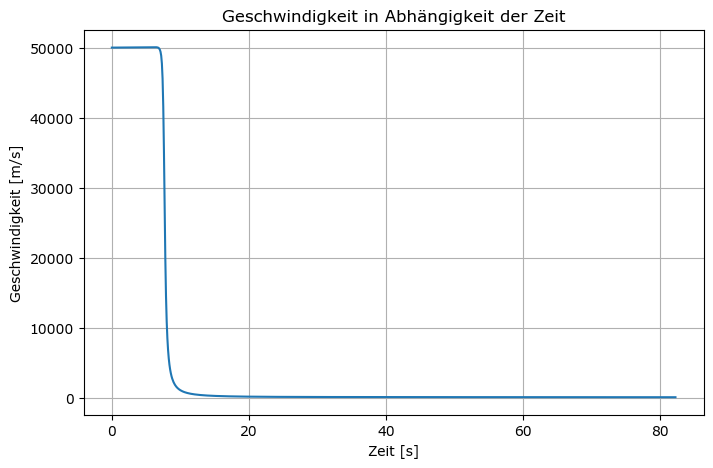

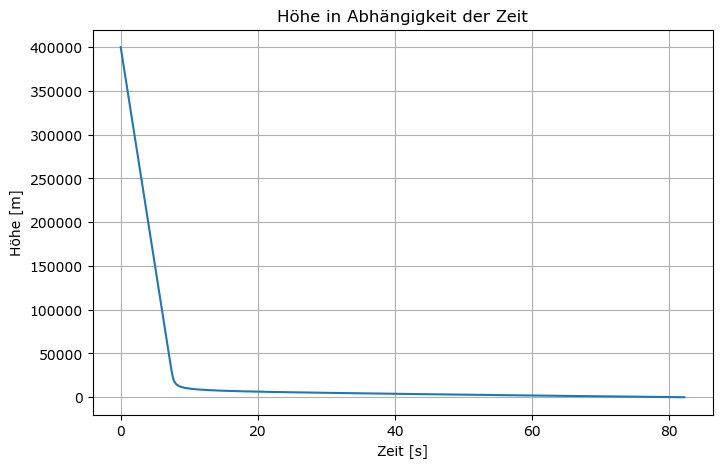

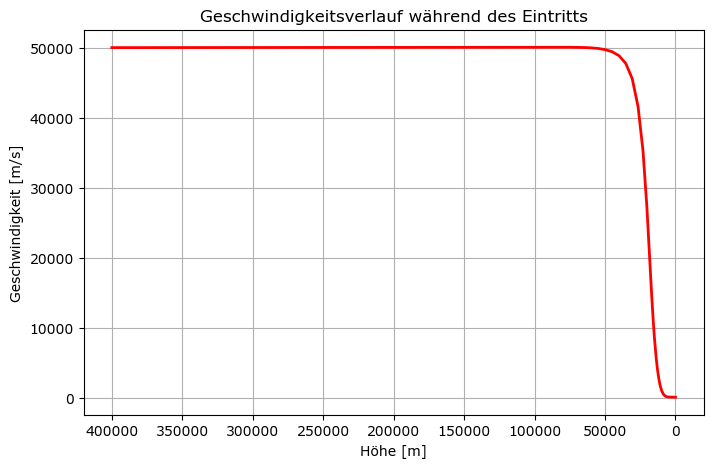

In [9]:
import numpy as np
import matplotlib.pyplot as plt

hoehe = 400000.0   # Start hoehe in m
R = 8.314462618          # universelle Gaskonstante [J/(mol*K)]
G = 6.67430e-11          # Gravitationskonstante [m^3/(kg*s^2)]
M_erde = 5.972e24        # Erdmasse [kg]
R_erde = 6.371e6         # Erdradius [m]

p0 = 101325.0            # Druck auf Meereshoehe [Pa]

Cw = 0.47
A = 0.05                 # Stirnflaeche [m^2]
m = 10.0                 # Masse [kg]

hoehen = []

def Gravitation_h(h):
    return G * M_erde / (R_erde + h)**2

def temperatur_h(h):
    h_km = h / 1000.0

    if h_km < 11:
        return 288.15 - 6.5 * h_km
    elif h_km < 20:
        return 216.65
    elif h_km < 32:
        return 216.65 + 1.0 * (h_km - 20)
    elif h_km < 47:
        return 228.65 + 2.8 * (h_km - 32)
    elif h_km < 51:
        return 270.65
    elif h_km < 71:
        return 270.65 - 2.8 * (h_km - 51)
    elif h_km < 86:
        return 214.65 - 2.0 * (h_km - 71)
    elif h_km < 100:
        return 186.87
    elif h_km < 120:
        return 186.87 + (360.0 - 186.87) * (h_km - 100) / 20.0
    elif h_km < 200:
        return 360.0 + (800.0 - 360.0) * (h_km - 120) / 80.0
    else:
        return 800.0

def molmasse_h(h):
    h_km = h / 1000.0

    if h_km < 100:
        return 0.0289644
    elif h_km < 120:
        return 0.0289644 + (0.020 - 0.0289644) * (h_km - 100) / 20.0
    elif h_km < 200:
        return 0.020 + (0.012 - 0.020) * (h_km - 120) / 80.0
    else:
        return 0.012

def luftdruck_h(h, p0):
    if h <= 0:
        return p0

    hs = np.linspace(0, h, 1000)

    T = np.array([temperatur_h(x) for x in hs])
    M = np.array([molmasse_h(x) for x in hs])
    g = np.array([Gravitation_h(x) for x in hs])

    f = (M * g) / (R * T)

    I = np.trapz(f, hs)

    return p0 * np.exp(-I)

def dichte_h(h):
    T = temperatur_h(h)
    M = molmasse_h(h)
    p = luftdruck_h(h, p0)
    return p * M / (R * T)
    
def beschleunigung(v, h, k):
    g = Gravitation_h(h)
    rho = dichte_h(h)
    return g - rho * k * v * abs(v)

def euler(v0, t0, hoehe, k, dt, n):
    v = v0
    t = t0
    h = hoehe

    results = [(t, v)]
    hoehen.clear()
    hoehen.append(h)

    for i in range(n):
        a = beschleunigung(v, h, k)

        v = v + dt * a
        h = h - v * dt
        t = t + dt

        if h < 0:
            h = 0

        hoehen.append(h)
        results.append((t, v))

        if h <= 0:
            break

    return results


werte = euler(
    v0=50000,
    t0=0,
    hoehe=hoehe,
    k=Cw * A / (2 * m),
    dt=0.1,
    n=100000
)

zeiten = [punkt[0] for punkt in werte]
geschwindigkeiten = [punkt[1] for punkt in werte]
hoehen_plot = hoehen[:len(zeiten)]


arr = np.array(geschwindigkeiten)

max_wert = np.max(arr)
position = np.argmax(arr)

print(f"{max_wert} m/s")  
print(f"{position*0.1} Sekunden") 
print(f"{hoehen_plot[position]}")

plt.figure(figsize=(8, 5))
plt.plot(zeiten, geschwindigkeiten)
plt.xlabel("Zeit [s]")
plt.ylabel("Geschwindigkeit [m/s]")
plt.title("Geschwindigkeit in Abhängigkeit der Zeit")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(zeiten, hoehen_plot)
plt.xlabel("Zeit [s]")
plt.ylabel("Höhe [m]")
plt.title("Höhe in Abhängigkeit der Zeit")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hoehen_plot, geschwindigkeiten, color='red', linewidth=2)
plt.gca().invert_xaxis()
plt.xlabel("Höhe [m]")
plt.ylabel("Geschwindigkeit [m/s]")
plt.title("Geschwindigkeitsverlauf während des Eintritts")
plt.grid(True)
plt.show()

In [17]:
def luftdruck_h(h, p0):
    if h <= 0:
        return p0

    hs = np.linspace(0, h, 1000)

    T = np.array([temperatur_h(x) for x in hs])
    M = np.array([molmasse_h(x) for x in hs])
    g = np.array([Gravitation_h(x) for x in hs])

    f = (M * g) / (R * T)

    I = np.trapz(f, hs)

    return p0 * np.exp(-I)

333.35033840084344


/private/var/mobile/Containers/Data/Application/7847E2DD-A906-4AAE-B541-8FED28C964CC/tmp/ipykernel_6787/1895096237.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(y, x)
